# Budget-Constrained Influence Maximization
### How close can cheap centrality heuristics get to the greedy algorithm?

DCIT 316 (Computational Models for Social Media Mining) semester project.

This notebook is the exploratory companion to the reproducible pipeline in
`src/` and `scripts/run_full_analysis.py`. It:

1. Loads the SNAP ego-Facebook dataset and reports basic graph statistics.
2. Demonstrates the Independent Cascade (IC) and Linear Threshold (LT)
   diffusion models on a small toy graph, so their mechanics are visible
   before trusting them on the full 4,039-node graph.
3. Runs a small, fast demo of greedy vs. heuristic seed selection directly
   in the notebook (reduced budget / MC runs, for interactivity).
4. Loads and displays the full experiment's results
   (`reports/results_table.csv` and `reports/figures/*.png`), which were
   generated by `scripts/run_full_analysis.py` at the paper's actual
   parameters (k up to 50, 200 Monte Carlo runs per estimate) -- that run
   takes several minutes, so it is run as a script rather than inline here.

See `PROJECT_BRIEF.md`, `data_card.md`, and `reports/interpretation.md` for
full context.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.graph_utils import load_graph, compute_basic_stats, print_stats
from src.diffusion_models import simulate_ic, simulate_lt
from src.evaluation import estimate_spread
from src.seed_selection import (
    degree_ranking, pagerank_ranking, eigenvector_ranking, betweenness_ranking,
    random_seeds, ranking_to_seed_sets, greedy_seeds_incremental,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Load the dataset and inspect basic graph statistics

In [2]:
graph = load_graph(ROOT / "data" / "facebook_combined.txt")
stats = compute_basic_stats(graph)
print_stats(stats)

Graph basic statistics
-----------------------
num_nodes: 4039
num_edges: 88234
avg_degree: 43.691013
min_degree: 1
max_degree: 1045
density: 0.010820
num_connected_components: 1
largest_component_size: 4039
largest_component_fraction: 1.000000
average_clustering_coefficient: 0.605547
stats_computation_seconds: 1.851805


The graph is a single connected component of 4,039 nodes and 88,234 edges,
with a high average clustering coefficient (~0.60) typical of ego-networks:
friend groups form dense, overlapping cliques around the anchor user.

## 2. Diffusion models on a small toy graph

Before trusting IC/LT on the full graph, sanity-check them on a graph small enough to reason about by hand: a "barbell"-like graph with two dense clusters joined by a bridge.

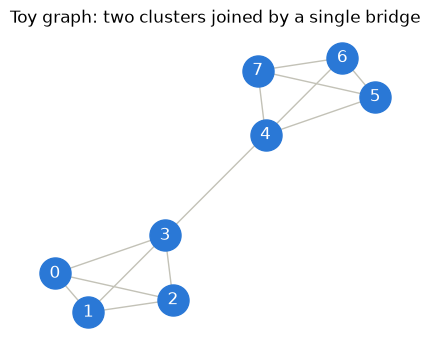

In [3]:
toy = nx.Graph()
cluster_a = [0, 1, 2, 3]
cluster_b = [4, 5, 6, 7]
toy.add_edges_from([(u, v) for i, u in enumerate(cluster_a) for v in cluster_a[i+1:]])
toy.add_edges_from([(u, v) for i, u in enumerate(cluster_b) for v in cluster_b[i+1:]])
toy.add_edge(3, 4)  # the only bridge between the two clusters

fig, ax = plt.subplots(figsize=(5, 4))
pos = nx.spring_layout(toy, seed=1)
nx.draw(toy, pos, ax=ax, with_labels=True, node_color="#2a78d6", edge_color="#c3c2b7",
        font_color="white", node_size=500)
ax.set_title("Toy graph: two clusters joined by a single bridge")
plt.show()

In [4]:
rng = np.random.default_rng(RANDOM_SEED)

# With p=1.0, IC deterministically cascades along every edge -> full spread.
full_spread = simulate_ic(toy, seeds=[0], p=1.0, rng=rng)
print("IC, p=1.0, seed={0}: activates", sorted(full_spread), "(expect: everyone)")

# With p=0.0, nothing beyond the seed activates.
no_spread = simulate_ic(toy, seeds=[0], p=0.0, rng=rng)
print("IC, p=0.0, seed={0}: activates", sorted(no_spread), "(expect: just {0})")

# A seed in cluster A only, at low p, usually stays within cluster A because
# it must cross the single bridge edge (3, 4) to reach cluster B.
np.random.seed(RANDOM_SEED)
low_p_runs = [simulate_ic(toy, seeds=[0], p=0.3, rng=np.random.default_rng(i)) for i in range(200)]
crossed_bridge = sum(1 for run in low_p_runs if 4 in run)
print(f"IC, p=0.3, seed={{0}}: crossed the bridge into cluster B in {crossed_bridge}/200 simulations")

IC, p=1.0, seed={0}: activates [0, 1, 2, 3, 4, 5, 6, 7] (expect: everyone)
IC, p=0.0, seed={0}: activates [0] (expect: just {0})
IC, p=0.3, seed={0}: crossed the bridge into cluster B in 31/200 simulations


In [5]:
# Linear Threshold: seeding all of cluster A should reliably flip cluster B
# too, since node 4 has 3 in-cluster neighbors (5,6,7) but its bridge
# neighbor (3) is the only *seeded* neighbor initially -- LT needs enough
# activated in-neighbors to cross the threshold, so watch what it takes.
rng = np.random.default_rng(RANDOM_SEED)
lt_from_bridge_side = [simulate_lt(toy, seeds=[0, 1, 2, 3], rng=np.random.default_rng(i)) for i in range(200)]
crossed = sum(1 for run in lt_from_bridge_side if 4 in run)
print(f"LT, seeds=cluster A (0,1,2,3): activated node 4 (bridge) in {crossed}/200 simulations")
print("This illustrates LT's threshold logic: crossing a weak bridge is harder than under IC with high p.")

LT, seeds=cluster A (0,1,2,3): activated node 4 (bridge) in 49/200 simulations
This illustrates LT's threshold logic: crossing a weak bridge is harder than under IC with high p.


## 3. Small interactive demo: greedy vs. heuristics

This cell runs the real pipeline machinery (CELF greedy + all heuristics) on
the full Facebook graph, but with a reduced budget and MC run count so it
finishes in seconds inside the notebook. The full-scale results (k up to 50,
200 MC runs, both diffusion models) are in Section 4 below, generated by
`scripts/run_full_analysis.py`.

In [6]:
DEMO_MAX_K = 10
DEMO_MC_RUNS = 50

greedy_demo = greedy_seeds_incremental(graph, model="IC", max_k=DEMO_MAX_K, mc_runs=DEMO_MC_RUNS, seed=RANDOM_SEED)
print("Greedy order (first 10):", greedy_demo["order"])
print("Cumulative spread at each step:", [round(s, 1) for s in greedy_demo["cumulative_spread"]])

Greedy order (first 10): [1993, 107, 2611, 1800, 1684, 2328, 1238, 3437, 1305, 2128]
Cumulative spread at each step: [150.6, 221.5, 251.3, 273.9, 288.2, 299.9, 310.8, 318.6, 325.3, 331.4]


In [7]:
demo_rankings = {
    "degree": degree_ranking(graph),
    "pagerank": pagerank_ranking(graph),
    "eigenvector": eigenvector_ranking(graph),
}
demo_random = random_seeds(graph, max_k=DEMO_MAX_K, seed=RANDOM_SEED)

k = 10
rows = []
for name, ranking in demo_rankings.items():
    seed_set = ranking[:k]
    spread = estimate_spread(graph, seed_set, model="IC", mc_runs=DEMO_MC_RUNS, seed=RANDOM_SEED + 1)
    rows.append({"method": name, "spread_at_k10": spread})
rows.append({"method": "greedy", "spread_at_k10": greedy_demo["cumulative_spread"][k - 1]})
rows.append({
    "method": "random",
    "spread_at_k10": estimate_spread(graph, demo_random, model="IC", mc_runs=DEMO_MC_RUNS, seed=RANDOM_SEED + 1),
})

demo_df = pd.DataFrame(rows).sort_values("spread_at_k10", ascending=False).reset_index(drop=True)
demo_df

,method,spread_at_k10
0,greedy,331.44
1,degree,299.26
2,pagerank,236.36
3,eigenvector,179.36
4,random,125.28


Note: this is a quick, reduced-precision demo (50 MC runs, betweenness
centrality omitted here because it takes ~90s even on the full graph -- see
the module docstring in `src/seed_selection.py`). The paper's actual numbers
use 200 MC runs and include all six methods; those are loaded next.

## 4. Full experiment results

Generated by `scripts/run_full_analysis.py` (run separately -- see `README.md` for how to reproduce). Loaded here, not recomputed.

In [8]:
results = pd.read_csv(ROOT / "reports" / "results_table.csv")
results

,diffusion_model,method,budget_k,expected_spread,runtime_seconds,spread_pct_of_greedy,runtime_pct_of_greedy
0,IC,greedy,5,263.150,18.843983,100.000000,100.000000
1,IC,degree,5,235.575,0.002729,89.521186,0.014485
2,IC,pagerank,5,235.575,0.179720,89.521186,0.953726
3,IC,betweenness,5,231.700,94.202505,88.048641,499.907609
4,IC,eigenvector,5,179.260,0.795593,68.120844,4.222001
5,IC,random,5,40.945,0.000373,15.559567,0.001978
6,IC,greedy,10,301.395,18.980012,100.000000,100.000000
7,IC,degree,10,307.070,0.002729,101.882911,0.014381
8,IC,pagerank,10,250.715,0.179720,83.184857,0.946891
9,IC,betweenness,10,245.800,94.202505,81.554107,496.324787


In [9]:
pd.set_option("display.max_rows", 100)
pivoted = results.pivot_table(
    index=["method"], columns=["diffusion_model", "budget_k"], values="spread_pct_of_greedy"
)
pivoted

diffusion_model          IC                                              LT  \
budget_k                 5           10          20          50          5    
method                                                                        
betweenness       88.048641   81.554107   83.069882   89.160609   88.176336   
degree            89.521186  101.882911   98.269650   86.311787  100.000000   
eigenvector       68.120844   60.971483   55.523754   47.753880   24.086067   
greedy           100.000000  100.000000  100.000000  100.000000  100.000000   
pagerank          89.521186   83.184857   83.085864   93.477181  100.000000   
random            15.559567   39.902785   72.950748   79.925341    6.264630   

diffusion_model                                      
budget_k                 10          20          50  
method                                               
betweenness       88.141840   91.501439   86.283051  
degree            92.951994   96.090269   83.892929  
eigenvector       24.494318   23.881088   20.824216  
greedy           100.000000  100.000000  100.000000  
pagerank          99.098245   96.215579   94.904483  
random             8.820491   26.377761   35.561124

### Figures

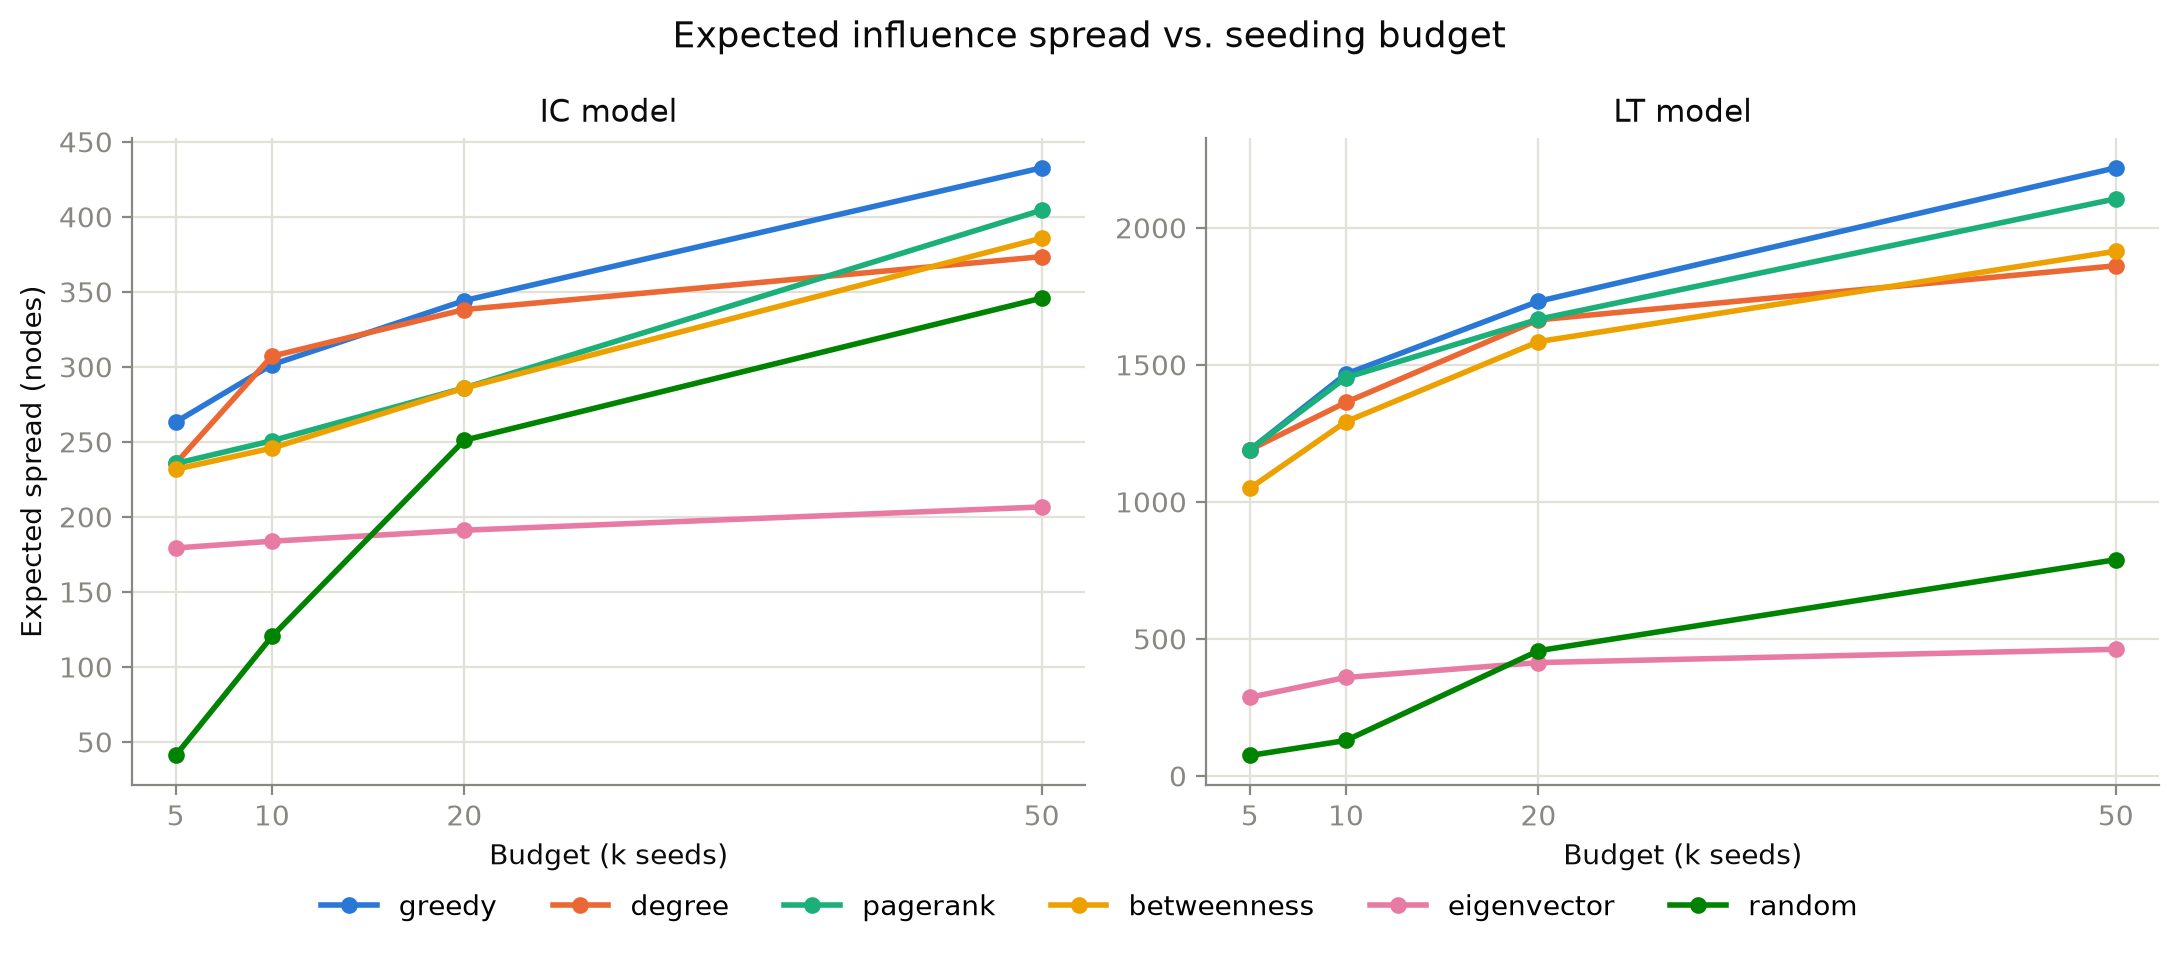

In [10]:
display(Image(filename=str(ROOT / "reports" / "figures" / "spread_vs_budget.png")))

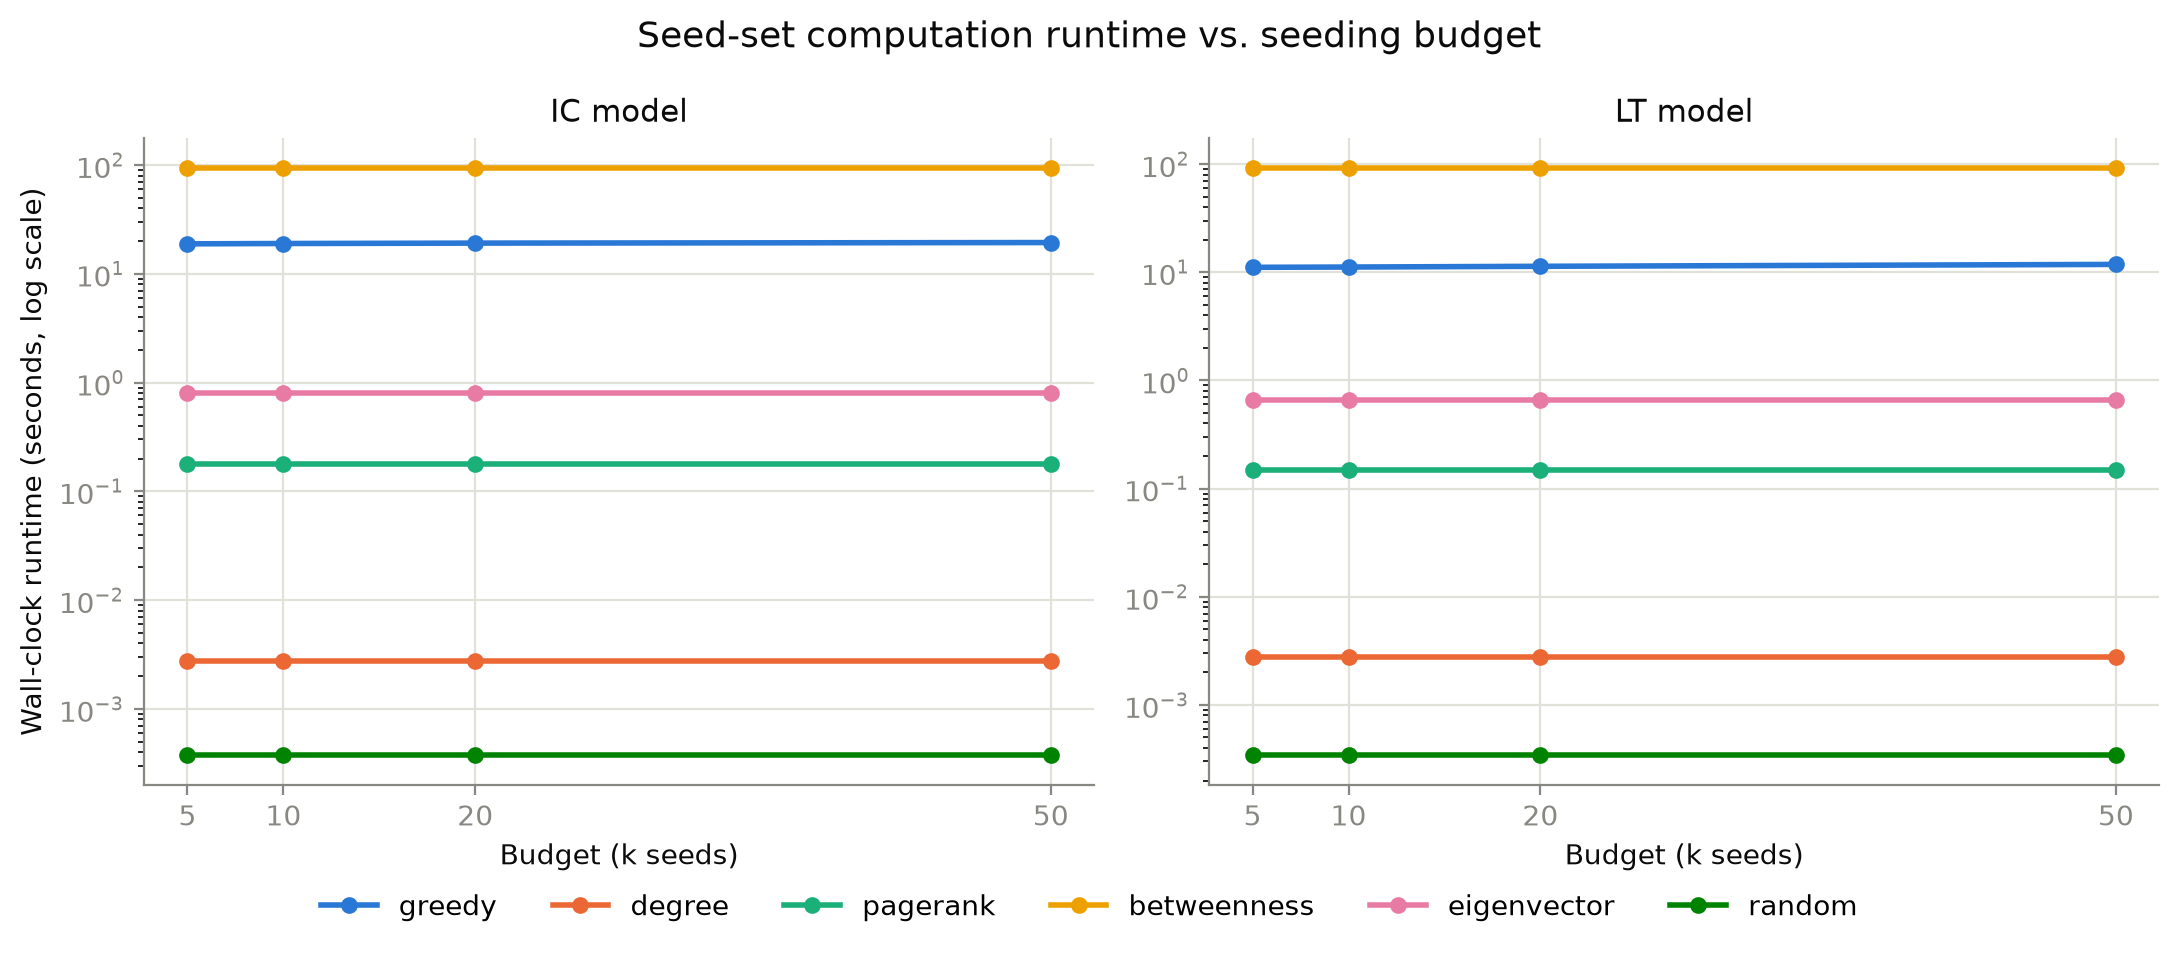

In [11]:
display(Image(filename=str(ROOT / "reports" / "figures" / "runtime_vs_budget.png")))

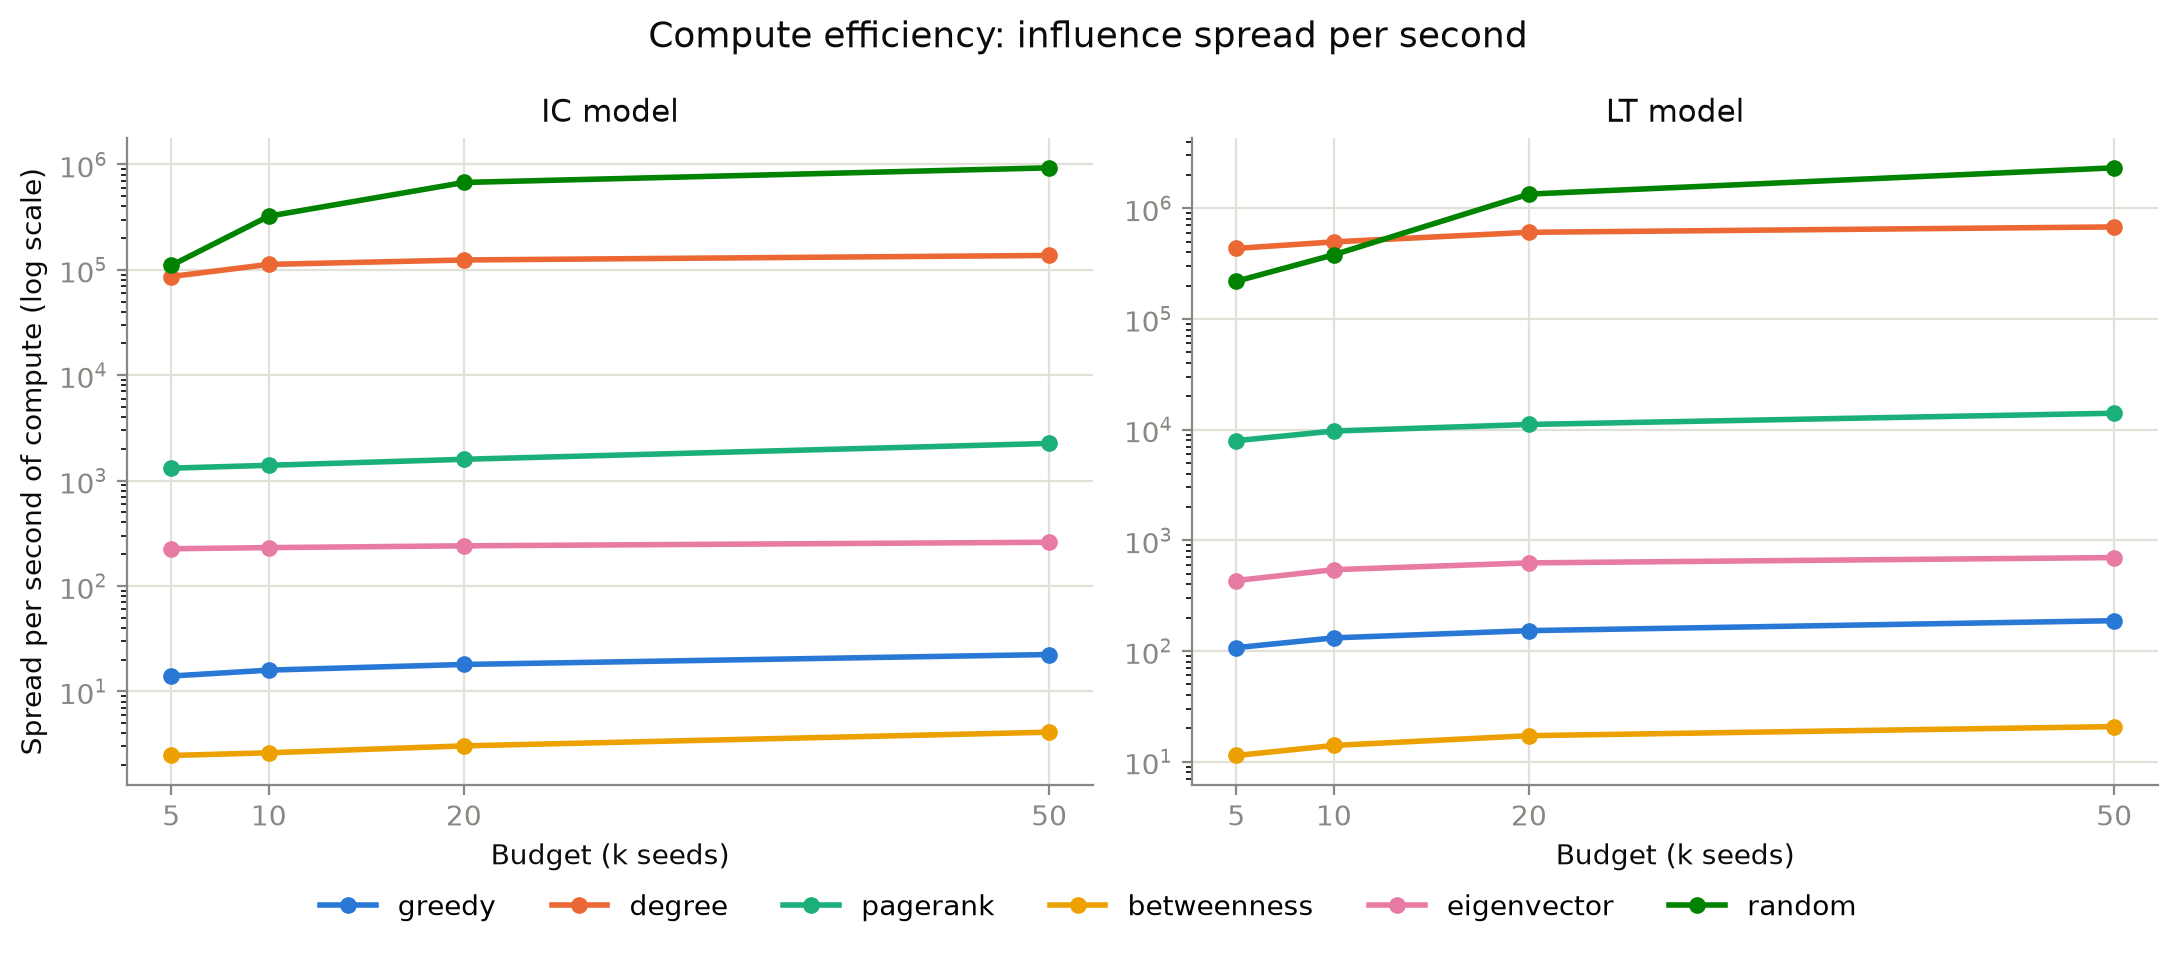

In [12]:
display(Image(filename=str(ROOT / "reports" / "figures" / "efficiency_chart.png")))

## 5. Summary

See `reports/interpretation.md` for the full, auto-generated technical
summary (including flagged surprising findings, e.g. cases where a heuristic
matched or exceeded greedy's Monte Carlo spread estimate at a given budget).
That file, plus this notebook's figures and `results_table.csv`, are the
inputs for writing the paper itself.